## Setup

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.transforms.functional as TF
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, random_split,Dataset

import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pytorch_msssim import ssim

from clone_repo.lq_embed.inference import vqvae_encoder, TwoLayerConv1x1


torch.manual_seed(42)

## Data Pipeline

### Configuration

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available else "No GPU")

img_size = 128
batch_size = 8
epochs = 5
lr = 1e-3

class Args:
  img_encoder_weight = "preset/pretrained/associate_2.ckpt"
  cat_prompt_embedding = False
  use_pos_embedding = False
  use_att_pool = False

args = Args()

True
NVIDIA GeForce RTX 3050 Laptop GPU


### Transform & Fungsi degrade (for LQ)

In [31]:
transform = T.Compose([
  T.CenterCrop(178),
  T.Resize((img_size, img_size)),
  T.ToTensor()
])

def degrade(img_tensor):
  # img_tensor: (C,H,W) [0,1]
  # downscale => upscale (blur effect)
  img = TF.resize(img_tensor,(img_size//2, img_size//2))
  img = TF.resize(img,(img_size,img_size))
  # tambah noise ringan
  noise = 0.02 * torch.rand_like(img)
  img = torch.clamp(img + noise, 0.0, 1.0)
  return img

### Dataset Wrapper (Retur LQ, HQ)

In [32]:
class CelebALocalDataset(Dataset):
  def __init__(self, img_dir, transform,max_samples=2000):
    self.paths = [os.path.join(img_dir,p) for p in os.listdir(img_dir)]
    self.paths = self.paths[:max_samples]
    self.transform = transform
  
  def __len__(self):
    return len(self.paths)

  def __getitem__(self, idx):
    img_path = self.paths[idx]
    img = Image.open(img_path).convert("RGB")

    img = self.transform(img)

    hq = img
    lq = degrade(img)
    return lq, hq
  

### Split train/val + DataLoader

In [33]:
dataset = CelebALocalDataset(img_dir="./data/celeba/img_align_celeba", transform=transform, max_samples=2000)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size,val_size])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=0)

lq,hq = next(iter(train_loader))
print("LQ:", lq.shape, "HQ:", hq.shape)


LQ: torch.Size([8, 3, 128, 128]) HQ: torch.Size([8, 3, 128, 128])


### Visualisasi Cepat

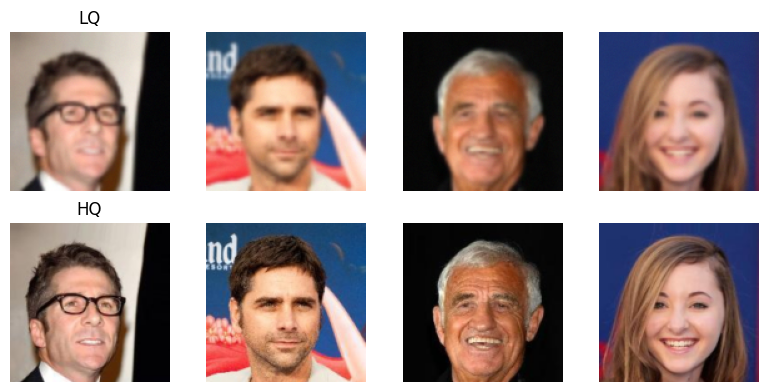

In [34]:
def show_pair(lq,hq, n=4):
  plt.figure(figsize=(8,4))
  for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(lq[i].permute(1,2,0).cpu())
    plt.axis("off")
    if i == 0 : plt.title("LQ")
    plt.subplot(2,n,i+1+n)
    plt.imshow(hq[i].permute(1,2,0).cpu())
    plt.axis("off")
    if i == 0: plt.title("HQ")
  plt.tight_layout(); plt.show()

show_pair(lq,hq)

## Baseline Model

### CNN Biasa

In [35]:
class SimpleRestorationCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(3,32,3,padding=1),
      nn.ReLU(inplace=True),

      nn.Conv2d(32,64,3,padding=1),
      nn.ReLU(inplace=True),

      nn.Conv2d(64,32,3,padding=1),
      nn.ReLU(inplace=True),
      
      nn.Conv2d(32,3,3,padding=1),
      nn.Sigmoid()
    )
  def forward(self,x):
    return self.net(x)
  
model = SimpleRestorationCNN().to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Params: {num_params/1e6:.2f}M")
x = torch.randn(1,3,128,128).to(device)
print(model(x).shape)

Params: 0.04M
torch.Size([1, 3, 128, 128])


## Training Loop

### Perceptual Loss

In [36]:
class VGGPerceptualLoss(torch.nn.Module):
  def __init__(self):
    super().__init__()
    vgg = models.vgg16(pretrained=True).features[:16]
    for param in vgg.parameters():
      param.requires_grad = False
    self.vgg = vgg.eval()
  
  def forward(self,pred,target):
    pred_feat= self.vgg(pred)
    target_feat=self.vgg(target)
    return F.l1_loss(pred_feat,target_feat)

In [37]:
def ssim_loss(pred,target):
  return 1-ssim(pred,target,data_range=1.0, size_average=True)

### CNN Model Training

In [38]:
criterion = nn.L1Loss()
perceptual_loss = VGGPerceptualLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model,loader):
  model.train()
  total_loss = 0.0

  for lq,hq in loader:
    lq,hq = lq.to(device), hq.to(device)

    pred = model(lq)

    l1 = criterion(pred,hq)
    ssim_l = ssim_loss(pred,hq)
    perc = perceptual_loss(pred,hq)

    loss = l1 + 0.1 * ssim_l + 0.1 * perc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  return total_loss / len(loader)

@torch.no_grad()
def validate(model,loader):
  model.eval()
  total_loss = 0.0
  for lq,hq in loader:
    lq,hq = lq.to(device), hq.to(device)
    pred = model(lq)

    l1 = criterion(pred,hq)
    ssim_l = ssim_loss(pred,hq)
    perc = perceptual_loss(pred,hq)

    loss = l1 + 0.1 * ssim_l + perc * 0.1

    total_loss += loss.item()
  return total_loss / len(loader)

d:\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\LENOVO GAMING/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100.0%


In [42]:
epochs = 5

train_losses = []
val_losses = []

for ep in range(epochs):
  train_loss = train_one_epoch(model, train_loader)
  val_loss = validate(model, val_loader)

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/5 | Train Loss: 0.0500 | Val Loss: 0.0476
Epoch 2/5 | Train Loss: 0.0487 | Val Loss: 0.0481
Epoch 3/5 | Train Loss: 0.0480 | Val Loss: 0.0458
Epoch 4/5 | Train Loss: 0.0480 | Val Loss: 0.0497
Epoch 5/5 | Train Loss: 0.0466 | Val Loss: 0.0446


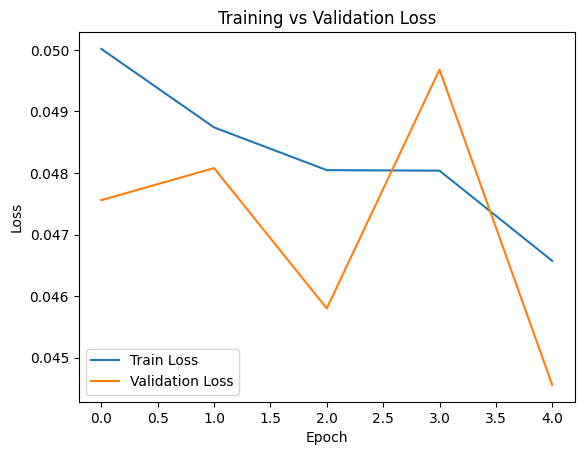

In [43]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

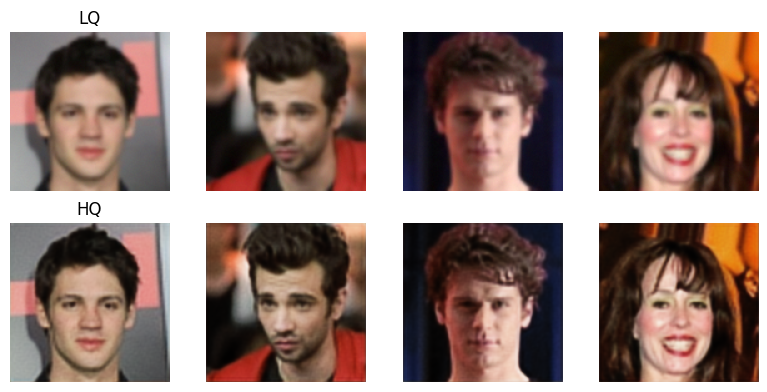

In [40]:
model.eval()
lq,hq = next(iter(val_loader))
lq = lq.to(device)
with torch.no_grad():
  pred = model(lq).cpu()

show_pair(lq.cpu(), pred.cpu(), n=4)